In [32]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.src.applications.mobilenet_v3 import preprocess_input
from pathlib import Path
import matplotlib.pyplot as plt

In [33]:
# Data paths and parameters
train_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
img_size = (224, 224)
batch_size = 32
project_root = Path('/home/groggy/projects/Image-Classification-Explainability')

In [34]:
train_datagen = ImageDataGenerator(
    #rescale=1./224,
    #preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.
Number of classes: 9
Training samples: 7200
Validation samples: 1800


## Architecture Testing Zone

**Baseline (from previous notebook):**
- GlobalAveragePooling2D → Dense(9, softmax)
- Trainable params: ~4,617
- Best val_accuracy: 0.2589 (25.89%)

**Current Configuration:**
- You can modify the architecture below to test improvements

In [35]:
# Build base model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep frozen for now

print(f"Base model output shape: {base_model.output_shape}")
print(f"Base model has {len(base_model.layers)} layers")

Base model output shape: (None, 7, 7, 960)
Base model has 187 layers


In [36]:
# EXPERIMENT: Build classifier head
# Modify this architecture to test different configurations

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', name='dense_512')(x)
x = Dropout(0.5, name='dropout_1')(x)
x = Dense(256, activation='relu', name='dense_256')(x)
x = Dropout(0.3, name='dropout_2')(x)
predictions = Dense(num_classes, activation='softmax', name='predictions')(x)

# Option 3: Add your own architecture here!
# x = Dense(???, activation='relu')(x)
# ...

model = Model(inputs=base_model.input, outputs=predictions)

print(f"\\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

\nTotal parameters: 3,622,025
Trainable parameters: 625,673
Non-trainable parameters: 2,996,352


In [37]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


I0000 00:00:1776284671.680146   18389 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_86845__.173


225/225 ━━━━━━━━━━━━━━━━━━━━ 94s 353ms/step - accuracy: 0.9176 - loss: 0.2515 - val_accuracy: 0.9917 - val_loss: 0.0281
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 62s 274ms/step - accuracy: 0.9914 - loss: 0.0265 - val_accuracy: 0.9822 - val_loss: 0.0426
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 64s 286ms/step - accuracy: 0.9912 - loss: 0.0226 - val_accuracy: 0.9661 - val_loss: 0.1098
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 62s 277ms/step - accuracy: 0.9892 - loss: 0.0345 - val_accuracy: 0.9822 - val_loss: 0.0655
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 63s 282ms/step - accuracy: 0.9928 - loss: 0.0255 - val_accuracy: 0.9883 - val_loss: 0.0433
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 64s 285ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9967 - val_loss: 0.0079
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 61s 270ms/step - accuracy: 0.9942 - loss: 0.0186 - val_accuracy: 0.9689 - val_loss: 0.1167
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 60s 269ms/step - accuracy: 0.9914 - loss: 0.0281 - val

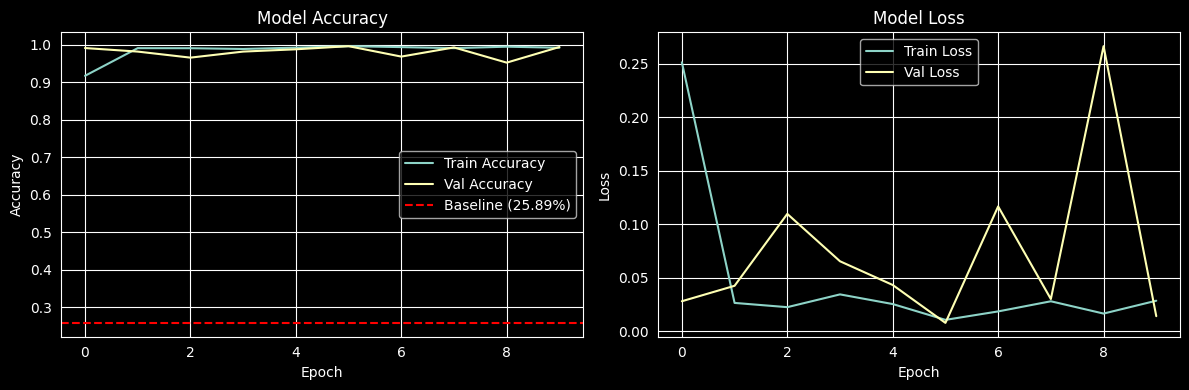

In [39]:
# Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axhline(y=0.2589, color='r', linestyle='--', label='Baseline (25.89%)')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [40]:
# Results summary
best_val_acc = max(history.history['val_accuracy'])
final_val_acc = history.history['val_accuracy'][-1]
baseline_acc = 0.2589

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Baseline validation accuracy:     {baseline_acc:.4f} (25.89%)")
print(f"Current best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Final validation accuracy:        {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Improvement over baseline:        {(best_val_acc - baseline_acc):.4f} ({(best_val_acc - baseline_acc)*100:.2f}%)")
print("=" * 60)

if best_val_acc > baseline_acc:
    print("✓ Architecture improved performance!")
else:
    print("✗ No improvement - try different architecture")

RESULTS SUMMARY
Baseline validation accuracy:     0.2589 (25.89%)
Current best validation accuracy: 0.9967 (99.67%)
Final validation accuracy:        0.9944 (99.44%)
Improvement over baseline:        0.7378 (73.78%)
✓ Architecture improved performance!


In [41]:
# Save model if improved
if best_val_acc > baseline_acc:
    save_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Improved.keras'
    model.save(save_path)
    print(f'✓ Model saved to: {save_path}')
else:
    print('Model not saved (no improvement over baseline)')

✓ Model saved to: /home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved.keras
